In [1]:
from pathlib import Path
import decoupler as dc
import pandas as pd
import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import scvi
import sys

sys.path.extend(["../../scripts","../../scripts/xenium"])
import readwrite
from preprocessing import subsample
from integration import transfer_labels_knn, evaluate_label_transfer, find_neighbor_same_donor

cfg = readwrite.config()

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/__init__.py:44: F

## Params

In [2]:
condition_palette = pd.read_csv(cfg['xenium_metadata_dir'] + 'condition_palette.csv',index_col=0).iloc[:,0].to_dict()
donor_palette = pd.read_csv(cfg['xenium_metadata_dir'] + 'donor_palette.csv',index_col=0).iloc[:,0].to_dict()
gene_sets_palette = pd.read_csv(cfg['xenium_metadata_dir'] + 'gene_sets_palette.csv',index_col=0).iloc[:,0].to_dict()
cell_type_palette = pd.read_csv(cfg['xenium_metadata_dir'] + 'cell_type_palette.csv',index_col=0).iloc[:,0].to_dict()

palettes = {
    "condition": condition_palette,
    "donor_corrected": donor_palette,
    "gene_sets": gene_sets_palette,
    "cell_type": cell_type_palette,
    "leiden_0.6_named": gene_sets_palette,
}

xenium_dir = Path(cfg["xenium_processed_dir"])
xenium_count_correction_dir = Path(cfg["xenium_count_correction_dir"])
xenium_std_seurat_analysis_dir = Path(cfg["xenium_std_seurat_analysis_dir"])
xenium_cell_type_annotation_dir = Path(cfg["xenium_cell_type_annotation_dir"])
results_dir = Path(cfg["results_dir"])

# input params
cellcharter_dir = "cellcharter_cohort"
correction_method = "raw"
segmentation = "proseg_expected"
condition = "all"
panel = "all"
normalisation = "lognorm"
reference = "GEO_GSE178341"
method = "rctd_class_aware"
level = "Level1"
xenium_levels = ["segmentation", "condition", "panel", "donor", "sample"]
name_malignant = "Epi"

# qc params
min_n_counts = 20

# fixed params
BATCH_KEY = "dataset_id"
SPATIAL_KEY = "spatial"

segmentations_filter = [segmentation]
conditions_filter = [condition] if condition != "all" else None
panels_filter = [panel] if panel != "all" else None

leiden_names = {}
leiden_names[0.6] = {
  0 : "Cycling_high",
  1 : "Goblet_Inflammatory",
  2 : "Transit-amplifying",
  3 : "Stem-like",
  4 : "Stress_Inflammatory",
  5 : "Chemokine_EMT",
  6 : "Goblet_MUC",

}

# Read results

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/spatialdat

Exclude 169V peritoneal sample
Could not find annotation file for ('proseg_expected', 'CRC_PDO_DEV', 'hImmune_v1_mm', '8_OY6Hsmallmiddle', 'output-XETG00059__0033028__8_OY6Hsmallmiddle__20250811__161841'): /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/cell_type_annotation/proseg_expected/CRC_PDO_DEV/hImmune_v1_mm/8_OY6Hsmallmiddle/output-XETG00059__0033028__8_OY6Hsmallmiddle__20250811__161841/lognorm/reference_based/GEO_GSE178341/rctd_class_aware/Level1/single_cell/labels.parquet
Could not find annotation file for ('proseg_expected', 'CRC_PDO_DEV', 'hImmune_v1_mm', '7_OY6Hsmall', 'output-XETG00059__0033028__7_OY6Hsmall__20250811__161841'): /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/cell_type_annotation/proseg_expected/CRC_PDO_DEV/hImmune_v1_mm/7_OY6Hsmall/output-XETG00059__0033028__7_OY6Hsmall__20250811__161841/lognorm/reference_based/GEO_GSE178341/rctd_class_aware/Level1/single_cell/labels.parquet
Could not find 

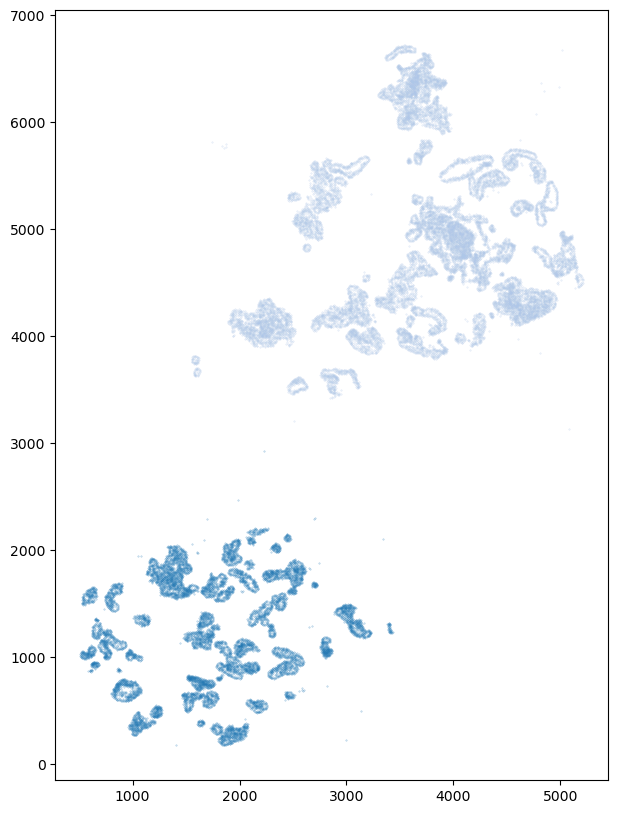

Removing 6 cells from excluded samples of 9_11_OY6H_middle_and_big
8samples


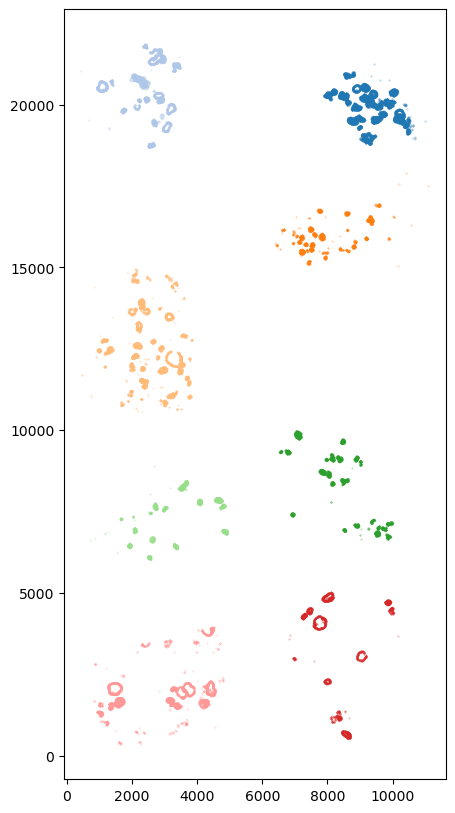

Removing 48 cells from excluded samples of 8samples
18samples


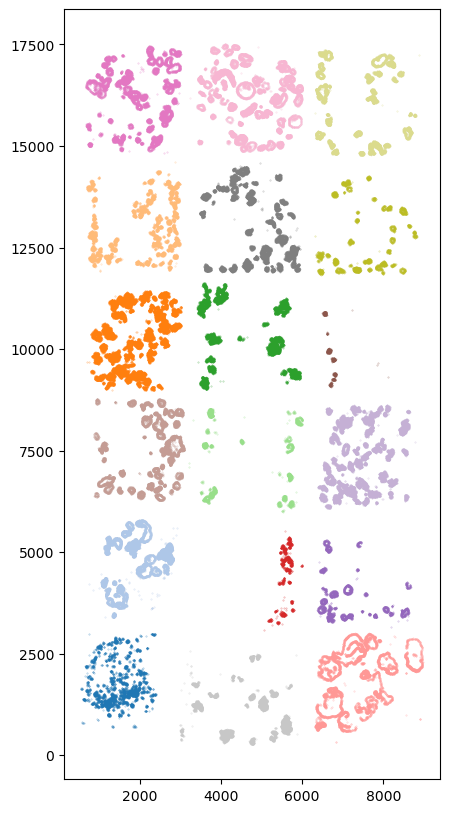

Removing 59063 cells from excluded samples of 18samples


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Keeping only run2 samples for CRC_PDO 1GAA and 077I


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Changing condition from CRC_PDO to CRC_PDO_CAF for 18042 cells


...

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Filtering out 17796 cells creating outlier leiden cluster after integration
Filtering out 110596 cells with less than 20 counts


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Filtering out 28128 cells from bad spatial regions
cohort info:


,donor,sample
CRC_PDO_DEV,6,6
CRC,14,14
CRC_PDO_CAF,10,10
CRC_PDO,38,38


In [3]:
# read samples
xenium_paths, xenium_annot_paths = readwrite.discover_xenium_paths(
    analysis_dir=xenium_std_seurat_analysis_dir,
    data_dir=xenium_dir,
    annotation_dir=xenium_cell_type_annotation_dir,
    correction_dir=xenium_count_correction_dir,
    normalisation=normalisation,
    reference=reference,
    method=method,
    level=level,
    correction_methods_filter=[correction_method],
    segmentations_filter=[segmentation],
    conditions_filter=conditions_filter,
    panels_filter=panels_filter,
)


# set transcripts=True to load individual transcripts positions)
if correction_method != "raw":
    ads = readwrite.read_count_correction_samples(xenium_paths, [correction_method])
else:
    ads = {}
    ads["raw"] = readwrite.read_xenium_samples(xenium_paths["raw"], anndata=True, pool_mode="thread", max_workers=6)

# remove 169V sample
print("Exclude 169V peritoneal sample")
ads['raw'] = { k:v for k,v in ads['raw'].items() if k[-2] != '169V' }

# add cell type annotation from raw to all correction methods
readwrite.read_annotations(ads, [correction_method], xenium_annot_paths, level, max_workers=8)

# split 18samples and 8samples, keep only samples needed for analysis according to csvs
samples2split = ['18samples','8samples','9_11_OY6H_middle_and_big']
samples2split_dict = {k[-2]: k for k in ads['raw'].keys() if k[-2] in samples2split}
coords_csv_dict = {k: cfg["xenium_metadata_dir"] + f"Regions_coordinates_{k}.csv" for k in samples2split}
readwrite.split_samples_by_coords(ads, samples2split_dict, coords_csv_dict, plot = True)

# concat samples
genes = [v.var_names for k, v in ads[correction_method].items()]
common_genes = list(set(genes[0]).intersection(*genes[1:]))

adata = sc.concat({k: v for k, v in ads[correction_method].items()}, label="dataset_id", join="outer")[
    :, common_genes
].copy()


# create metadata, full cell identifiers
adata.obs[xenium_levels] = pd.DataFrame(adata.obs["dataset_id"].tolist(), index=adata.obs.index, columns=xenium_levels)
adata.obs["correction_method"] = correction_method
adata.obs['cell_id'] = 'proseg-' + adata.obs['cell_id'].astype(str)
adata.obs['full_id'] = adata.obs[['segmentation', 'condition', 'panel', 'donor', 'sample','cell_id']].agg('_'.join, axis=1)
adata.obs["donor_corrected"] = adata.obs["donor_corrected"].fillna(adata.obs["donor"])
adata.obs["sample_corrected"] = adata.obs["sample_corrected"].fillna(adata.obs["sample"])

# all other conditions are Epi cells
adata.obs.loc[adata.obs['condition'] != 'CRC', level] = 'Epi'

# keep only run2 samples for 1GAA and 077I
print('Keeping only run2 samples for CRC_PDO 1GAA and 077I')
run2samples2keep = ['output-XETG00059__0003381__1GAA__20250505__170803','output-XETG00059__0003381__077I__20250505__170803']
adata = adata[
    ~(
        (adata.obs['condition'] == 'CRC_PDO') 
        & (adata.obs['donor'].isin(['077I','1GAA'])) 
        & (~(adata.obs['sample'].isin(run2samples2keep)))
    )
].copy()


# correct condition label for split samples
ix_correct_condition = (
    (adata.obs['condition'] == 'CRC_PDO') 
    & (adata.obs['donor_corrected'].isin(['1HVQ_big','1HVQ_big_CAFs'])))
print('Changing condition from CRC_PDO to CRC_PDO_CAF for', sum(ix_correct_condition),'cells')
adata.obs.loc[ix_correct_condition,'condition'] = 'CRC_PDO_CAF'

# exclude few CAFs that were not washed out
#     adata_sample = adata[adata.obs["donor_corrected"] == "07WM_CAFs"].copy()
#     sc.pp.normalize_total(adata_sample)
#     sc.pp.log1p(adata_sample)
#     sc.pp.neighbors(adata_sample)
#     sc.tl.leiden(adata_sample)
#     sc.tl.umap(adata_sample)
#     sc.pl.umap(adata_sample, color=["leiden","LUM","PDGFRA"])
#     adata_sample.obs[adata_sample.obs['leiden']=='8'].to_csv(cfg['xenium_metadata_dir']+"07WM_CAFs_cells_to_exclude.csv")
df_cells_to_exclude_07WM_CAFs = pd.read_csv(cfg['xenium_metadata_dir']+"07WM_CAFs_cells_to_exclude.csv",index_col=0)
adata = adata[
    ~(
        (adata.obs["donor_corrected"]=="07WM_CAFs") 
        & (adata.obs["cell_id"].isin(df_cells_to_exclude_07WM_CAFs["cell_id"]))
    )
].copy()
print("Filtering out",len(df_cells_to_exclude_07WM_CAFs),"CAF cells from 07WM_CAFs")

# exclude bad QC cells creating leiden outlier after data integration
df_cells_to_exclude_leiden_outlier = pd.read_csv(cfg['xenium_metadata_dir']+"cells_to_exclude_leiden_outlier.csv",index_col=0)
adata = adata[~(adata.obs["full_id"].isin(df_cells_to_exclude_leiden_outlier["full_id"]))].copy()
print("Filtering out",len(df_cells_to_exclude_leiden_outlier),"cells creating outlier leiden cluster after integration")

# apply QC
sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=False)
idx_qc = (adata.obs["total_counts"] > min_n_counts)
print('Filtering out',sum(~idx_qc),f'cells with less than {min_n_counts} counts')
adata = adata[idx_qc].copy()

# apply QC to bad spatial regions
if segmentation == 'proseg_expected':
    df_cells_qc = pd.read_csv(cfg['xenium_metadata_dir']+f"xenium_CRC_PDO_{segmentation}_cells_QC.csv",index_col=0)
    adata = adata[~adata.obs["full_id"].isin(df_cells_qc["full_id"])].copy()
    print('Filtering out',len(df_cells_qc),'cells from bad spatial regions')

print("cohort info:")
df_ = pd.DataFrame(columns=['donor','sample'])
for cond in adata.obs["condition"].unique():
    df_.loc[cond,'donor'] = adata.obs.query(f"condition == '{cond}'")['donor_corrected'].nunique()
    df_.loc[cond,'sample'] = adata.obs.query(f"condition == '{cond}'")['sample_corrected'].nunique()
df_

In [4]:
# adata_sample = adata[(adata.obs['condition'] == 'CRC_PDO') & (adata.obs['donor'] == 'OAFN')].copy()
# adata_sample.obs = adata_sample.obs.join(df_cells_qc[(df_cells_qc['condition'] == 'CRC_PDO') & (df_cells_qc['donor'] == 'OAFN')],rsuffix='_y')

# sc.pl.spatial(adata_sample,spot_size=10,color='donor_y')

## gene set scoring

In [5]:
# dc.mt.ulm(adata, gene_sets, tmin=0)
# adata.obs["ulm_label"] = adata.obsm["score_ulm"].idxmax(1)

## bbknn all

In [6]:
do_subsample = False

# subset to malignant cells
adata_malignant = adata[
    (adata.obs[level] == name_malignant)
].copy()
adata_malignant.layers["counts"] = adata_malignant.X.copy()

if do_subsample:
    # subsample (for sanity check, not final results)
    adata_malignant = subsample(adata_malignant, obs_key="sample_corrected", n_obs=10_000)

# preprocess
print('preprocessing')
sc.pp.normalize_total(adata_malignant)
sc.pp.log1p(adata_malignant)
sc.pp.pca(adata_malignant)

# integrate, cluster, umap
print('bbknn')
sc.external.pp.bbknn(adata_malignant, batch_key="sample_corrected")
print('leiden')
for r in [0.6,0.8]:
    sc.tl.leiden(adata_malignant,flavor='igraph',n_iterations=2,resolution=r,key_added=f'leiden_{r}')
print('umap')
sc.tl.umap(adata_malignant)

if not do_subsample:
    # save
    p = Path(cfg['results_dir']+f"xenium/integration/{correction_method}/{segmentation}/adata_malignant.h5ad")
    p.parent.mkdir(parents=True, exist_ok=True)
    del adata_malignant.obs['dataset_id']
    adata_malignant.obs_names = adata_malignant.obs['full_id']
    adata_malignant.write(p)
    # adata_malignant.obs[['full_id','leiden_1.4','leiden_1.6','leiden_2']].to_csv('../../scratch/cells_passing_QC_leiden_higher_res.csv',index=False)

# subset to shared CRC donors
donors_crc = adata_malignant.obs.query("condition=='CRC'")["donor_corrected"].unique()
donors_crcpdo = adata_malignant.obs.query("condition=='CRC_PDO'")["donor_corrected"].unique()
shared_donors = np.intersect1d(donors_crc, donors_crcpdo)
adata_shared_donors_malignant = adata_malignant[
    adata_malignant.obs["condition"].isin(["CRC", "CRC_PDO"]) &
    adata_malignant.obs["donor_corrected"].isin(shared_donors)]

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


preprocessing
bbknn
leiden
umap


... storing 'cell_id' as categorical
... storing 'fov' as categorical
... storing 'region' as categorical
... storing 'donor' as categorical
... storing 'sample' as categorical
... storing 'donor_corrected' as categorical
... storing 'sample_corrected' as categorical
... storing 'Level1' as categorical
... storing 'segmentation' as categorical
... storing 'condition' as categorical
... storing 'panel' as categorical
... storing 'correction_method' as categorical


In [ ]:
# name leiden clusters (after analysis below)
resolutions = [0.6]
for r in resolutions:
    leiden_key = f'leiden_{r}'
    
    # name leiden clusters if in dict
    if r in leiden_names:
        adata_malignant.obs[f'leiden_{r}_named'] = adata_malignant.obs[f'leiden_{r}'].astype(int).replace(leiden_names[r]).astype('category')
        adata_shared_donors_malignant.obs[f'leiden_{r}_named'] = adata_shared_donors_malignant.obs[f'leiden_{r}'].replace(leiden_names[r]).astype('category')

adata_malignant.obs.to_parquet(cfg['results_dir']+f'xenium/integration/{correction_method}/{segmentation}/adata_malignant_obs.parquet')

# load saved bbknn results

In [4]:
p = Path(cfg['results_dir']+f"xenium/integration/{correction_method}/{segmentation}/adata_malignant.h5ad")
adata_malignant = sc.read(p)
# subset to shared CRC donors
donors_crc = adata_malignant.obs.query("condition=='CRC'")["donor_corrected"].unique()
donors_crcpdo = adata_malignant.obs.query("condition=='CRC_PDO'")["donor_corrected"].unique()
shared_donors = np.intersect1d(donors_crc, donors_crcpdo)
adata_shared_donors_malignant = adata_malignant[
    adata_malignant.obs["condition"].isin(["CRC", "CRC_PDO"]) &
    adata_malignant.obs["donor_corrected"].isin(shared_donors)]

# plot bbknn results

In [8]:
resolutions = [0.6,0.8]

for r in resolutions:

    print(r)
    leiden_key = f'leiden_{r}'
    
    # name leiden clusters if in dict
    # if r in leiden_names:
    #     leiden_key +='_named'

    sc.tl.rank_genes_groups(adata_malignant,leiden_key)

    for s in ['dendrogram_'+leiden_key,leiden_key+'_colors']:
        if s in adata_malignant.uns:
            del adata_malignant.uns[s]

    sc.pl.rank_genes_groups_dotplot(
        adata_malignant,
        groupby=leiden_key,
        n_genes=5,
        show = False
    )
    fig = plt.gcf()
    p = Path(cfg['figures_dir']+f"xenium/integration/{correction_method}/{segmentation}/de_{leiden_key}_adata_malignant_dotplot.png")
    p.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(p, dpi=300, bbox_inches="tight")
    plt.close(fig)

    df_de = sc.get.rank_genes_groups_df(adata_malignant, group=None)
    p = Path(cfg['results_dir']+f"xenium/integration/{correction_method}/{segmentation}/de_{leiden_key}_adata_malignant.csv")
    p.parent.mkdir(parents=True, exist_ok=True)
    df_de.to_csv(p)



    # umaps
    for n,ad in zip(["adata_malignant", "adata_shared_donors_malignant"],[adata_malignant, adata_shared_donors_malignant]):
        for color in ["condition", "donor_corrected",leiden_key]:
            if color == 'donor_corrected' and n == 'adata_malignant':
                pal = None
            else:
                pal = palettes.get(color)
            
            sc.pl.umap(
                ad,
                color=color,
                show=False,
                s=.5,
                palette=pal,
            )

            fig = plt.gcf()

            p = Path(cfg['figures_dir']+f"xenium/integration/{correction_method}/{segmentation}/bbknn_umap_{color}_{n}.png")
            p.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(p, dpi=300, bbox_inches="tight")
            plt.close(fig)

        # umap top 2 DE genes
        top2 = df_de.groupby('group').apply(lambda x: x.nlargest(2, 'scores'))

        sc.pl.umap(
            ad,
            color=top2['names'].values,
            show=False,
            s=.5,ncols=4,
        )

        fig = plt.gcf()
        p = Path(cfg['figures_dir']+f"xenium/integration/{correction_method}/{segmentation}/bbknn_umap_top2_DE_{n}.png")
        p.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(p, dpi=300, bbox_inches="tight")
        plt.close(fig)

0.6


/tmp/ipykernel_2137336/3195275799.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top2 = df_de.groupby('group').apply(lambda x: x.nlargest(2, 'scores'))
/tmp/ipykernel_2137336/3195275799.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top2 = df_de.groupby('group').apply(lambda x: x.nlargest(2, 'scores'))
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/scanpy/plotting/_utils.py:482: ImplicitModificationWarning: Trying to modify attribute `._un

0.8


/tmp/ipykernel_2137336/3195275799.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top2 = df_de.groupby('group').apply(lambda x: x.nlargest(2, 'scores'))
/tmp/ipykernel_2137336/3195275799.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top2 = df_de.groupby('group').apply(lambda x: x.nlargest(2, 'scores'))
/tmp/ipykernel_2137336/3195275799.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behav

In [9]:
for r in resolutions:
    print(r)
    leiden_key = f'leiden_{r}'
    
    # name leiden clusters if in dict
    if r in leiden_names:
        leiden_key +='_named'

    for n,ad in zip(["adata_malignant", "adata_shared_donors_malignant"],[adata_malignant, adata_shared_donors_malignant]):

        for plot_condition in ["CRC", "CRC_PDO"]: 

            adata_plot = adata_malignant[adata_malignant.obs["condition"] == plot_condition]
            adata_plot.obs[leiden_key] = adata_plot.obs[leiden_key].astype(str)

            df_props = adata_plot.obs.groupby(['donor_corrected','sample_corrected'],observed=True)[leiden_key].value_counts(normalize=True).unstack().reset_index()
            # df_props["full_sample_id"] = df_props[xenium_levels].astype(str).agg(" | ".join, axis=1)
            # df_props = df_props.query(f"segmentation == '{segmentation}'").sort_values("donor")

            # Step 2: Dynamically set the figure size
            num_samples = len(df_props.index)
            fig_height = max(6, num_samples * 0.4)

            # Step 3: Create the figure and axes object
            fig, ax = plt.subplots(figsize=(12, fig_height))

            # Step 4: Plot directly onto the created axes object
            df_props.plot(kind="barh", stacked=True, ax=ax, width=0.8,color=palettes.get(leiden_key))


            # Step 6: Customize the plot
            ax.set_title(f"Proportion of leiden clusters by sample - {segmentation} - {plot_condition}", fontsize=16)
            ax.set_xlabel("Proportion", fontsize=12)
            ax.set_ylabel("Sample ID", fontsize=12)
            ax.set_yticklabels(df_props["donor_corrected"])
            ax.legend(title=leiden_key, bbox_to_anchor=(1.02, 1), loc="upper left")
            ax.set_xlim(0, 1)
            plt.tight_layout()

            p = Path(cfg['figures_dir']+f"xenium/integration/{correction_method}/{segmentation}/bbknn_umap_leiden_clusters_composition_{plot_condition}_{n}.png")
            p.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(p, dpi=300, bbox_inches="tight")
            plt.close(fig)

            # df_props.to_csv(f'../../scratch/celltype_composition_{segmentation}_{reference}_{level}.csv')

0.6


KeyError: 'leiden_0.6_named'

In [ ]:
condition_key="condition"
label_to_transfer="donor_corrected"

for ref_condition, query_condition in [("CRC", "CRC_PDO"), ("CRC_PDO", "CRC")]:
    # USAGE 1: kNN search on PCA embeddings
    predicted_donors_pca = transfer_labels_knn(
        adata=adata_shared_donors_malignant,
        ref_condition=ref_condition,
        query_condition=query_condition,
        condition_key=condition_key,
        label_to_transfer=label_to_transfer,
        use_rep='X_pca' 
    )

    # USAGE 2: bkknn graph
    predicted_donors_graph = transfer_labels_knn(
        adata=adata_shared_donors_malignant, 
        ref_condition=ref_condition,
        query_condition=query_condition,
        condition_key=condition_key,
        label_to_transfer=label_to_transfer,
        use_graph_key="connectivities" 
    )

    # Evaluation 
    true_donors = adata_shared_donors_malignant.obs.loc[adata_shared_donors_malignant.obs[condition_key] == query_condition, label_to_transfer]

    for normalize in ["true", "pred", None]:

        disp=evaluate_label_transfer(
            true_labels=true_donors,
            predicted_labels=predicted_donors_pca,
            title="Confusion Matrix from PCA (row normalized)",
            normalize="true", 
            save_path=cfg['figures_dir']+f"xenium/integration/{correction_method}/{segmentation}/pca_transfer_confusion_matrix_{query_condition}_{normalize=}.png",
            show=False
        )

        disp2=evaluate_label_transfer(
            true_labels=true_donors,
            predicted_labels=predicted_donors_graph,
            title="Confusion Matrix from bbknn (row normalized)",
            normalize="true",
            save_path=cfg['figures_dir']+f"xenium/integration/{correction_method}/{segmentation}/bbknn_transfer_confusion_matrix_{query_condition}_{normalize=}.png",
            show=False
        )

## niche analysis by MP for CRC

In [ ]:
import squidpy as sq

cluster_key = 'leiden_0.6_named'

adata.obs_names = adata.obs['full_id']

# add malignant program annotation to full adata
adata.obs[f'{level}_with_programs'] = adata.obs['Level1']
adata.obs.loc[adata_malignant.obs_names,f'{level}_with_programs'] = adata_malignant.obs[cluster_key]
adata.obs[f'{level}_with_programs'] = adata.obs[f'{level}_with_programs'].astype('category')
adata.obs['sample'] = adata.obs['sample'].astype('category')

# enrichment for crc
adata_crc = adata[adata.obs["condition"] == "CRC"]
sq.gr.spatial_neighbors(adata_crc, radius=20, spatial_key='spatial',library_key='sample',coord_type='generic',set_diag=True)
sq.gr.nhood_enrichment(adata_crc, cluster_key=f'{level}_with_programs')
sq.pl.nhood_enrichment(adata_crc, cluster_key=f'{level}_with_programs', method="average", figsize=(5, 5))

## mapping

In [ ]:
adata_shared_donors_malignant.obs_names_make_unique()
find_neighbor_same_donor(adata_shared_donors_malignant, source_cond="CRC_PDO", target_cond="CRC")

for donor in adata_shared_donors_malignant.obs["donor_corrected"].unique():
    print(donor)

    # CRC_donor (all cells and malignant only)
    adata_donor = adata[(adata.obs["condition"] == "CRC") & (adata.obs["donor_corrected"] == donor)]
    adata_donor_malignant = adata_donor[(adata_donor.obs[level] == name_malignant)]

    # CRC PDO donor
    adata_shared_donors_malignant_donor = adata_shared_donors_malignant[
          (adata_shared_donors_malignant.obs["condition"] == "CRC") 
        & (adata_shared_donors_malignant.obs["donor"] == donor)].copy()

    # CRC donor matching cells
    adata_shared_donors_malignant_donor_knn = adata_shared_donors_malignant[
        np.array(adata_shared_donors_malignant.obs.query(f"condition == 'CRC_PDO' and donor_corrected == '{donor}'")["neighbor_CRC_index"])
    ].copy()

    # plot
    f, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].scatter(*adata_donor.obsm["spatial"].T, c="lightgrey", s=.5, alpha=0.3)
    axs[0].scatter(*adata_shared_donors_malignant_donor_knn.obsm["spatial"].T, c="red", s=1, alpha=0.5,label='matching PDO')
    axs[0].set_title("All cell types")
    axs[1].scatter(*adata_donor_malignant.obsm["spatial"].T, c="lightgrey", s=.5, alpha=0.3)
    axs[1].scatter(*adata_shared_donors_malignant_donor_knn.obsm["spatial"].T, c="red", s=1, alpha=0.5,label='matching PDO')
    axs[1].set_title("Malignant cells")

    plt.suptitle(donor)
    p = Path(cfg['figures_dir']+f"xenium/integration/{correction_method}/{segmentation}/pca_mapping_{donor}.png")
    p.parent.mkdir(parents=True, exist_ok=True)
    f.savefig(p, dpi=300, bbox_inches="tight")
    plt.close(f)
    # plt.show()

# bbknn chromium / CRC_PDO

In [ ]:
# load chromium, subset xneium to malignant CRC
ad_sc = sc.read_10x_h5(cfg['scrnaseq_processed_dir']+'CRC_PDO/Chromium_merged_processed/RNA_counts.h5')
ad_sc.obs = ad_sc.obs.join(pd.read_parquet(cfg['scrnaseq_processed_dir']+'CRC_PDO/Chromium_merged_processed/metadata.parquet').set_index('cell_id'))
ad_sc.obs['patient'] = ad_sc.obs['patient'].replace({'14VS': '14V5'})
ad_sc.obs['donor_corrected'] = ad_sc.obs['patient']
ad_sc.obs['condition'] = 'chromium'
ad_sc.layers['counts'] = ad_sc.X

adata_malignant_PDO = adata_malignant[adata_malignant.obs["condition"] == "CRC_PDO"].copy()
sc.pp.subsample(adata_malignant_PDO, n_obs=len(ad_sc), copy=False)

# concat modalities
genes = [adata_malignant_PDO.var_names, ad_sc.var_names]
common_genes = list(set(genes[0]).intersection(*genes[1:]))

ad_sc_crc = sc.concat({'chromium':ad_sc, 'xenium':adata_malignant_PDO}, label="modality", join="outer")[
    :, common_genes
].copy()


# subset to common donors
u = ad_sc.obs['donor_corrected'].unique()
ad_sc_pdo_shared_donors = ad_sc_crc[ad_sc_crc.obs['donor_corrected'].isin(u)]
# ad_sc_pdo_shared_donors.obs[['condition','donor_corrected']].drop_duplicates()

# preprocess
sc.pp.normalize_total(ad_sc_pdo_shared_donors)
sc.pp.log1p(ad_sc_pdo_shared_donors)
sc.pp.pca(ad_sc_pdo_shared_donors)

# integrate, cluster, umap
sc.external.pp.bbknn(ad_sc_pdo_shared_donors, batch_key="condition")
# sc.tl.leiden(ad_sc_crc,flavor='igraph',n_iterations=2,resolution=.6)
sc.tl.umap(ad_sc_pdo_shared_donors)


# save
p = Path(cfg['results_dir']+f"xenium/integration/{correction_method}/{segmentation}/ad_sc_pdo_shared_donors.h5ad")
p.parent.mkdir(parents=True, exist_ok=True)
ad_sc_pdo_shared_donors.write(p)

In [ ]:
for n,ad in zip(["ad_sc_pdo_shared_donors"],[ad_sc_pdo_shared_donors]):
    for color in ["condition", "donor_corrected"]:
        sc.pl.umap(
            ad,
            color=color,
            show=False,
        )

        fig = plt.gcf()

        p = Path(cfg['figures_dir']+f"xenium/integration/{correction_method}/{segmentation}/bbknn_umap_{color}_{n}.png")
        p.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(p, dpi=300, bbox_inches="tight")
        plt.close(fig)

In [ ]:
condition_key="condition"
label_to_transfer="donor_corrected"

for ref_condition, query_condition in [("CRC_PDO", "chromium"), ("chromium", "CRC_PDO")]:
    # USAGE 1: kNN search on PCA embeddings
    predicted_donors_pca = transfer_labels_knn(
        adata=ad_sc_pdo_shared_donors,
        ref_condition=ref_condition,
        query_condition=query_condition,
        condition_key=condition_key,
        label_to_transfer=label_to_transfer,
        use_rep='X_pca' 
    )

    # USAGE 2: bkknn graph
    predicted_donors_graph = transfer_labels_knn(
        adata=ad_sc_pdo_shared_donors, 
        ref_condition=ref_condition,
        query_condition=query_condition,
        condition_key=condition_key,
        label_to_transfer=label_to_transfer,
        use_graph_key="connectivities" 
    )

    # Evaluation 
    true_donors = ad_sc_pdo_shared_donors.obs.loc[ad_sc_pdo_shared_donors.obs[condition_key].str.contains(query_condition), label_to_transfer]

    for normalize in ["true", "pred", None]:

        disp=evaluate_label_transfer(
            true_labels=true_donors,
            predicted_labels=predicted_donors_pca,
            title=f"Confusion Matrix from PCA ({normalize} normalized)",
            normalize="true", 
            text_kw={"fontsize": 5},
            save_path=cfg['figures_dir']+f"xenium/integration/{correction_method}/{segmentation}/pca_chromium_transfer_confusion_matrix_{query_condition}_{normalize=}.png",
            show=False
        )

        disp2=evaluate_label_transfer(
            true_labels=true_donors,
            predicted_labels=predicted_donors_graph,
            title=f"Confusion Matrix from bbknn ({normalize} normalized)",
            normalize="true",
            text_kw={"fontsize": 5},
            save_path=cfg['figures_dir']+f"xenium/integration/{correction_method}/{segmentation}/bbknn_chromium_transfer_confusion_matrix_{query_condition}_{normalize=}.png",
            show=False
        )

## CoDa kNN / not kNN

In [ ]:
import coda
donor = 'OUC1'

adata_donor = adata[(adata.obs["condition"] == "CRC") & (adata.obs["donor"] == donor)]
adata_donor_malignant = adata_donor[(adata_donor.obs[level] == name_malignant)]

adata_shared_donors_malignant_donor = adata_shared_donors_malignant[(adata_shared_donors_malignant.obs["condition"] == "CRC") & (adata_shared_donors_malignant.obs["donor"] == donor)].copy()
adata_shared_donors_malignant_donor_knn = adata_shared_donors_malignant[
    np.array(adata_shared_donors_malignant.obs.query(f"condition == 'CRC_PDO' and donor == '{donor}'")["neighbor_CRC_index"])
].copy()
adata_shared_donors_malignant_donor_knn.obs_names = adata_shared_donors_malignant_donor_knn.obs_names.str[:-2]
adata_shared_donors_malignant_donor_not_knn = adata_shared_donors_malignant_donor[adata_shared_donors_malignant_donor.obs_names.difference(adata_shared_donors_malignant_donor_knn.obs_names)].copy()


# f, axs = plt.subplots(1, 2, figsize=(12, 6))
# axs[0].scatter(*adata_donor.obsm["spatial"].T, c="lightgrey", s=.5, alpha=0.3)
# axs[0].scatter(*adata_shared_donors_malignant_donor_knn.obsm["spatial"].T, c="red", s=1, alpha=0.5,label='matching PDO')
# axs[0].set_title("All cell types")
# axs[1].scatter(*adata_donor_malignant.obsm["spatial"].T, c="lightgrey", s=.5, alpha=0.3)
# axs[1].scatter(*adata_shared_donors_malignant_donor_knn.obsm["spatial"].T, c="red", s=1, alpha=0.5,label='matching PDO')
# axs[1].set_title("Malignant cells")
# plt.suptitle(donor)
# plt.show()

df_plot = pd.concat((pd.DataFrame(adata_donor.obsm['spatial'],index=adata_donor.obs_names,columns=['x','y']),adata_donor.obs[[level]]),axis=1)
plt.figure(figsize=(10,10))
ax = sns.scatterplot(data=df_plot, x="x", y="y", s=3, alpha=0.3, hue=level)
handles, labels = ax.get_legend_handles_labels()
for handle in handles:
    handle.set_markersize(10.0) 
ax.legend(handles, labels)

In [ ]:
sq.gr.spatial_neighbors(adata_donor, radius=10, spatial_key='spatial',coord_type='generic',set_diag=True)

knnidx,knndist = coda.sparse_to_knn(adata_donor.obsp['spatial_connectivities'])
adata_ilr = coda.get_ilr(adata_donor, knnidx=knnidx, label_key=level)
adata_ilr_knn = adata_ilr[adata_ilr.obs_names.isin(adata_shared_donors_malignant_donor_knn.obs_names)]
adata_ilr_not_knn = adata_ilr[adata_ilr.obs_names.isin(adata_shared_donors_malignant_donor_not_knn.obs_names)]

for adata_plot in [adata_ilr_knn, adata_ilr_not_knn]: 

    # sort by PC1 and normalize to 1
    PC1 = adata_plot.obsm['X_ilr_pca'][:,0]
    df_plot = pd.DataFrame(adata_plot.obsm['X_composition'],columns=adata_plot.uns['X_knnlabels_columns'])
    df_plot = df_plot.iloc[np.argsort(PC1)].T
    df_plot.columns = np.arange(df_plot.shape[1])


    f, axs = plt.subplots(2,1,figsize=(30,10))

    ax = axs[0]
    ax = sns.heatmap(data=df_plot,ax=ax)
    ax.set_xticks([])
    ax.set_yticklabels(df_plot.index, rotation = 0)
    ax.set_ylabel('Cell types')
    ax.set_xlabel('Sorted ILR PC1 index')


    ax = axs[1]
    ax.stackplot(df_plot.columns, *df_plot.values, labels=df_plot.index)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel('% of neighboring cells')
    ax.set_xlabel('ILR PC1')
    ax.legend(
        title='Cell Type', 
        loc='center left', 
        bbox_to_anchor=(1.0, 0.5)
    )
    ax.margins(x=0, y=0)
    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend
    plt.show()

# old integration results

## scVI

In [17]:
integration_method = 'bbknn'
do_subsample = False

# subset to malignant cells
adata_malignant = adata[
    (adata.obs[level] == name_malignant)
].copy()
adata_malignant.layers["counts"] = adata_malignant.X.copy()

if do_subsample:
    # subsample (for sanity check, not final results)
    adata_malignant = subsample(adata_malignant, obs_key="sample_corrected", n_obs=10_000)

# preprocess
print('preprocessing')
sc.pp.normalize_total(adata_malignant)
sc.pp.log1p(adata_malignant)
sc.pp.pca(adata_malignant)

# integrate, cluster, umap
if integration_method == 'bbknn':
    print('bbknn')
    sc.external.pp.bbknn(adata_malignant, batch_key="sample_corrected")
    
elif integration_method == 'scvi':
    print('scvi')
    adata_malignant.layers["counts_round"] = adata_malignant.layers['counts'].copy()
    adata_malignant.layers["counts_round"].data = adata_malignant.layers["counts_round"].data.round()
    scvi.model.SCVI.setup_anndata(adata_malignant, layer="counts_round", batch_key="condition",categorical_covariate_keys=["donor_corrected"])

    model = scvi.model.SCVI(adata_malignant)
    model.train(early_stopping=True,enable_progress_bar=True)
    adata_malignant.obsm["X_scVI"] = model.get_latent_representation(adata_malignant).astype(np.float32)
    sc.pp.neighbors(adata_malignant, use_rep="X_scVI")

print('leiden')
for r in [0.6,0.8]:
    sc.tl.leiden(adata_malignant,flavor='igraph',n_iterations=2,resolution=r,key_added=f'leiden_{r}_{integration_method}')
print('umap')
sc.tl.umap(adata_malignant,key_added = f'X_umap_{integration_method}')


if not do_subsample:
    # save
    p = Path(cfg['results_dir']+f"xenium/integration/{correction_method}/{segmentation}/adata_malignant_{integration_method}.h5ad")
    p.parent.mkdir(parents=True, exist_ok=True)
    del adata_malignant.obs['dataset_id']
    adata_malignant.obs_names = adata_malignant.obs['full_id']
    adata_malignant.write(p)
    # adata_malignant.obs[['full_id','leiden_1.4','leiden_1.6','leiden_2']].to_csv('../../scratch/cells_passing_QC_leiden_higher_res.csv',index=False)

# subset to shared CRC donors
donors_crc = adata_malignant.obs.query("condition=='CRC'")["donor_corrected"].unique()
donors_crcpdo = adata_malignant.obs.query("condition=='CRC_PDO'")["donor_corrected"].unique()
shared_donors = np.intersect1d(donors_crc, donors_crcpdo)
adata_shared_donors_malignant = adata_malignant[
    adata_malignant.obs["condition"].isin(["CRC", "CRC_PDO"]) &
    adata_malignant.obs["donor_corrected"].isin(shared_donors)]

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


preprocessing
bbknn
leiden
umap


... storing 'cell_id' as categorical
... storing 'fov' as categorical
... storing 'region' as categorical
... storing 'Level1' as categorical
... storing 'donor' as categorical
... storing 'sample' as categorical
... storing 'donor_corrected' as categorical
... storing 'sample_corrected' as categorical
... storing 'segmentation' as categorical
... storing 'condition' as categorical
... storing 'panel' as categorical
... storing 'correction_method' as categorical


In [18]:
resolutions = [0.5,0.6,0.8,1,1.2]
resolutions = [0.6,0.8]

for r in resolutions:

    print(r)
    leiden_key = f'leiden_{r}_{integration_method}'
    
    # name leiden clusters if in dict
    # if r in leiden_names:
    #     leiden_key +='_named'

    sc.tl.rank_genes_groups(adata_malignant,leiden_key)

    for s in ['dendrogram_'+leiden_key,leiden_key+'_colors']:
        if s in adata_malignant.uns:
            del adata_malignant.uns[s]

    sc.pl.rank_genes_groups_dotplot(
        adata_malignant,
        groupby=leiden_key,
        n_genes=5,
        show = False
    )
    fig = plt.gcf()
    p = Path(cfg['figures_dir']+f"xenium/integration/{correction_method}/{segmentation}/de_{leiden_key}_adata_malignant_dotplot.png")
    p.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(p, dpi=300, bbox_inches="tight")
    plt.close(fig)

    df_de = sc.get.rank_genes_groups_df(adata_malignant, group=None)
    p = Path(cfg['results_dir']+f"xenium/integration/{correction_method}/{segmentation}/de_{leiden_key}_adata_malignant.csv")
    p.parent.mkdir(parents=True, exist_ok=True)
    df_de.to_csv(p)



    # umaps
    for n,ad in zip(["adata_malignant", "adata_shared_donors_malignant"],[adata_malignant, adata_shared_donors_malignant]):
        for color in ["condition", "donor_corrected",leiden_key]:
            if color == 'donor_corrected' and n == 'adata_malignant':
                pal = None
            else:
                pal = palettes.get(color)
            
            sc.pl.embedding(
                ad,
                f'X_umap_{integration_method}',
                color=color,
                show=False,
                s=.5,
                palette=pal,
            )

            fig = plt.gcf()

            p = Path(cfg['figures_dir']+f"xenium/integration/{correction_method}/{segmentation}/{integration_method}_umap_{color}_{n}.png")
            p.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(p, dpi=300, bbox_inches="tight")
            plt.close(fig)

        # umap top 2 DE genes
        top2 = df_de.groupby('group').apply(lambda x: x.nlargest(2, 'scores'))

        sc.pl.embedding(
            ad,
            f'X_umap_{integration_method}',
            color=top2['names'].values,
            show=False,
            s=.5,ncols=4,
        )

        fig = plt.gcf()
        p = Path(cfg['figures_dir']+f"xenium/integration/{correction_method}/{segmentation}/{integration_method}_umap_top2_DE_{n}.png")
        p.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(p, dpi=300, bbox_inches="tight")
        plt.close(fig)

0.6


/tmp/ipykernel_1778887/1668242711.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top2 = df_de.groupby('group').apply(lambda x: x.nlargest(2, 'scores'))
/tmp/ipykernel_1778887/1668242711.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top2 = df_de.groupby('group').apply(lambda x: x.nlargest(2, 'scores'))
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/scanpy/plotting/_utils.py:482: ImplicitModificationWarning: Trying to modify attribute `._un

0.8


/tmp/ipykernel_1778887/1668242711.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top2 = df_de.groupby('group').apply(lambda x: x.nlargest(2, 'scores'))
/tmp/ipykernel_1778887/1668242711.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top2 = df_de.groupby('group').apply(lambda x: x.nlargest(2, 'scores'))
/tmp/ipykernel_1778887/1668242711.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behav

In [ ]:
adata_sub = sc.pp.sample(adata_malignant, n=50_000, copy=True, rng=0)
sc.pp.neighbors(adata_sub, use_rep="X_scVI")
sc.tl.umap(adata_sub)

In [ ]:
sc.pl.umap(adata_sub,color=['condition','donor'])
sc.pl.umap(adata_sub,color=top2['names'].values)

for cond in adata_sub.obs["condition"].unique():
    sc.pl.umap(adata_sub[adata_sub.obs["condition"] == cond],color=['condition','donor'])
    sc.pl.umap(adata_sub[adata_sub.obs["condition"] == cond],color=top2['names'].values)

In [ ]:
adata_sub = sc.pp.sample(adata_shared_donors_malignant, n=50_000, copy=True, rng=0)
scvi.model.SCANVI.setup_anndata(
    adata_sub, layer="counts", batch_key="condition", labels_key="donor", unlabeled_category="nan"
)
model = scvi.model.SCANVI(adata_sub)
model.train(
    early_stopping=True,
    enable_progress_bar=True,
    plan_kwargs={
        "kl_weight": 1,
    },
)
adata_sub.obsm["X_scanVI"] = model.get_latent_representation(adata_sub).astype(np.float32)

In [ ]:
adata_sub = sc.pp.sample(adata_shared_donors_malignant, n=50_000, copy=True, rng=0)

scvi.model.SCVI.setup_anndata(adata_sub, layer="counts", batch_key="condition")
scvi_model = scvi.model.SCVI(adata_sub)
scvi_model.train(early_stopping=True, enable_progress_bar=True)

scanvi_model = scvi.model.SCANVI.from_scvi_model(
    scvi_model, adata=adata_sub, unlabeled_category="nan", labels_key="donor"
)
scanvi_model.train(max_epochs=100, early_stopping=True, enable_progress_bar=True)

adata_sub.obsm["X_scanVI"] = model.get_latent_representation(adata_sub).astype(np.float32)

In [ ]:
from scvi.external import SysVI

# Change the seed
scvi.settings.seed = 0

SysVI.setup_anndata(
    adata=adata_sub,
    batch_key="condition",
)
model2 = SysVI(
    adata=adata_sub,
)
# Example showing how to adjust loss weights
model2.train(
    early_stopping=True,
    enable_progress_bar=True,
    plan_kwargs={
        "kl_weight": 1,
        "z_distance_cycle_weight": 5,
        # Add additional parameters, such as number of epochs
    },
)
adata_sub.obsm["X_sysVI"] = model.get_latent_representation(adata_sub).astype(np.float32)

In [ ]:
sc.pp.neighbors(adata_sub, use_rep="X_scVI")
sc.tl.umap(adata_sub)
sc.pl.umap(adata_sub, color=["condition", "donor"])
# sc.pl.embedding(adata_sub[adata_sub.obs['condition']=='CRC'], basis='X_umap',color=['condition','donor'])
# sc.pl.embedding(adata_sub[adata_sub.obs['condition']=='CRC_PDO'], basis='X_umap',color=['condition','donor'])

In [ ]:
sc.pp.neighbors(adata_sub, use_rep="X_sysVI")
sc.tl.umap(adata_sub)
sc.pl.umap(adata_sub, color=["condition", "donor"])
sc.pl.umap(adata_sub[adata_sub.obs["condition"] == "CRC"], color=["condition", "donor"])
sc.pl.umap(adata_sub[adata_sub.obs["condition"] == "CRC_PDO"], color=["condition", "donor"])

In [ ]:
sc.pp.neighbors(adata_sub, use_rep="X_scanVI")
sc.tl.umap(adata_sub)
sc.pl.umap(adata_sub, color=["condition", "donor"])
sc.pl.umap(adata_sub[adata_sub.obs["condition"] == "CRC"], color=["condition", "donor"])
sc.pl.umap(adata_sub[adata_sub.obs["condition"] == "CRC_PDO"], color=["condition", "donor"])

## concord

In [ ]:
import concord as ccd

model = ccd.Concord(
    adata=adata_shared_donors_malignant,
    input_feature=adata_shared_donors_malignant.var["highly_variable"].values.tolist(),
    domain_key="condition",
)
model.fit_transform(output_key="X_cc")

sc.pp.neighbors(adata_shared_donors_malignant, use_rep="X_cc")
sc.tl.umap(adata_shared_donors_malignant)